In [16]:
# 1. Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

In [19]:
# Ajuste o caminho caso o notebook esteja em outra pasta
url = 'https://docs.google.com/spreadsheets/d/1Ou9RFvSBZHRtVLkEi45qsjfY8aB4dT1bYFz-cdeuwFw/export?format=xlsx'

def carregar_dados(fonte):
    """Carrega os dados brutos a partir de um caminho local ou URL de exportação do Forms/Sheets."""
    return pd.read_excel(fonte)

df = pd.read_excel(url)
print(df.shape)
df.head()

(22, 12)


,Carimbo de data/hora,nome,area,gerente,empresa,CSAT,faturamento,colaborativo,impacto,início,fim estimado,situacao
0,2026-09-07 15:31:26,Projeto Umbra,Mobile,Juliana Lima,Aurora Labs,5.0,2500,0,0,2024-03-09,2024-04-09,Concluído
1,2026-09-06 15:31:26,Projeto Constelação,Sites,Marcos Vinícius,Delta Consult,5.0,5000,5000,0,2024-04-19,2024-05-19,Concluído
2,2026-09-05 15:31:26,Projeto Solstício,Mobile,Rafael Souza,NimbusSoft,4.0,3000,0,0,2024-05-11,2024-06-11,Concluído
3,2026-09-04 15:31:26,Projeto Vetor,Desktop,Pedro de Pádua,Jagger CO,4.0,17000,0,0,2024-07-21,2024-08-21,Concluído
4,2026-09-03 15:31:26,Projeto Odisseia,Desktop,Marcos Vinícius,Delta Consult,4.0,7000,0,0,2024-08-01,2024-09-01,Concluído


In [3]:
mapa_colunas = {
    'Carimbo de data/hora': 'data_registro',                      # timestamp do formulário
    'nome': 'nome_projeto',
    'area': 'area',                                # dados / mobile / desktop / sites
    'gerente': 'responsavel',
    'empresa': 'cliente',
    'CSAT': 'satisfacao',
    'faturamento': 'valor_total_projeto',                 # valor contratado do projeto
    'colaborativo': 'valor_faturamento_colaborativo',     # valor faturado em parceria com outra empresa
    'impacto': 'projeto_de_impacto',                  # 0/1 -> binário para previsão futura
    'início': 'data_inicio',
    'fim estimado': 'data_fim',
    'situacao': 'status',                             # concluído / em andamento / iniciado
}

def padronizar_colunas(df, mapa=mapa_colunas):
    """Renomeia as colunas e avisa se alguma coluna esperada não veio na fonte (ex.: pergunta removida do Forms)."""
    colunas_ausentes = [c for c in mapa if c not in df.columns]
    if colunas_ausentes:
        print(f'[aviso] colunas esperadas não encontradas na fonte: {colunas_ausentes}')
    return df.rename(columns=mapa)

df = df.rename(columns=mapa_colunas)
df.head()


,data_registro,nome_projeto,area,responsavel,cliente,satisfacao,valor_total_projeto,valor_faturamento_colaborativo,projeto_de_impacto,data_inicio,data_fim,status
0,2026-09-07 15:31:26,Projeto Umbra,Mobile,Juliana Lima,Aurora Labs,5.0,2500,0,0,2024-03-09,2024-04-09,Concluído
1,2026-09-06 15:31:26,Projeto Constelação,Sites,Marcos Vinícius,Delta Consult,5.0,5000,5000,0,2024-04-19,2024-05-19,Concluído
2,2026-09-05 15:31:26,Projeto Solstício,Mobile,Rafael Souza,NimbusSoft,4.0,3000,0,0,2024-05-11,2024-06-11,Concluído
3,2026-09-04 15:31:26,Projeto Vetor,Desktop,Pedro de Pádua,Jagger CO,4.0,17000,0,0,2024-07-21,2024-08-21,Concluído
4,2026-09-03 15:31:26,Projeto Odisseia,Desktop,Marcos Vinícius,Delta Consult,4.0,7000,0,0,2024-08-01,2024-09-01,Concluído


In [4]:
df['projeto_de_impacto'] = df['projeto_de_impacto'].astype(bool)
df['status'] = df['status'].str.strip()
df['area'] = df['area'].str.strip()

print('Linhas duplicadas:', df.duplicated().sum())
print()
print('Valores nulos por coluna:')
print(df.isna().sum())
print()
print('Categorias de área:', df['area'].unique())
print('Categorias de status:', df['status'].unique())

Linhas duplicadas: 0

Valores nulos por coluna:
data_registro                     0
nome_projeto                      0
area                              0
responsavel                       0
cliente                           0
satisfacao                        7
valor_total_projeto               0
valor_faturamento_colaborativo    0
projeto_de_impacto                0
data_inicio                       0
data_fim                          0
status                            0
dtype: int64

Categorias de área: <StringArray>
['Mobile', 'Sites', 'Desktop', 'Dados']
Length: 4, dtype: str
Categorias de status: <StringArray>
['Concluído', 'Em andamento', 'Iniciado']
Length: 3, dtype: str


In [5]:
def limpar_dados(df):
    df = df.copy()
    df['projeto_de_impacto'] = df['projeto_de_impacto'].fillna(0).astype(int).astype(bool)
    df['status'] = df['status'].astype(str).str.strip()
    df['area'] = df['area'].astype(str).str.strip()

    # --- Tratamento da coluna CSAT (satisfacao) ---
    df['satisfacao'] = pd.to_numeric(df['satisfacao'], errors='coerce')
    fora_da_escala = df['satisfacao'].notna() & ~df['satisfacao'].between(0, 10)
    if fora_da_escala.any():
        print(f'[atenção] {fora_da_escala.sum()} valor(es) de CSAT fora da escala 0-10 foram descartados.')
        df.loc[fora_da_escala, 'satisfacao'] = np.nan

    concluido_sem_csat = (df['status'] == 'Concluído') & df['satisfacao'].isna()
    nao_concluido_com_csat = (df['status'] != 'Concluído') & df['satisfacao'].notna()
    print(f'Projetos concluídos sem CSAT registrado: {concluido_sem_csat.sum()}')
    print(f'Projetos não concluídos com CSAT já registrado (incomum, revisar): {nao_concluido_com_csat.sum()}')

    print('\nLinhas duplicadas:', df.duplicated().sum())
    print('\nValores nulos por coluna:')
    print(df.isna().sum())
    print('\nCategorias de área:', df['area'].unique())
    print('Categorias de status:', df['status'].unique())
    return df

df = limpar_dados(df)


Projetos concluídos sem CSAT registrado: 0
Projetos não concluídos com CSAT já registrado (incomum, revisar): 0

Linhas duplicadas: 0

Valores nulos por coluna:
data_registro                     0
nome_projeto                      0
area                              0
responsavel                       0
cliente                           0
satisfacao                        7
valor_total_projeto               0
valor_faturamento_colaborativo    0
projeto_de_impacto                0
data_inicio                       0
data_fim                          0
status                            0
dtype: int64

Categorias de área: <StringArray>
['Mobile', 'Sites', 'Desktop', 'Dados']
Length: 4, dtype: str
Categorias de status: <StringArray>
['Concluído', 'Em andamento', 'Iniciado']
Length: 3, dtype: str


In [6]:
df['ano_inicio'] = df['data_inicio'].dt.year
df['mes_inicio'] = df['data_inicio'].dt.month
df['ano_mes_inicio'] = df['data_inicio'].dt.to_period('M').astype(str)
df['duracao_dias'] = (df['data_fim'] - df['data_inicio']).dt.days

df[['nome_projeto', 'data_inicio', 'data_fim', 'duracao_dias', 'ano_mes_inicio']].head()


,nome_projeto,data_inicio,data_fim,duracao_dias,ano_mes_inicio
0,Projeto Umbra,2024-03-09,2024-04-09,31,2024-03
1,Projeto Constelação,2024-04-19,2024-05-19,30,2024-04
2,Projeto Solstício,2024-05-11,2024-06-11,31,2024-05
3,Projeto Vetor,2024-07-21,2024-08-21,31,2024-07
4,Projeto Odisseia,2024-08-01,2024-09-01,31,2024-08


/tmp/ipykernel_456/1996529979.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(faturamento_mensal['ano_mes_inicio'], rotation=45, ha='right')


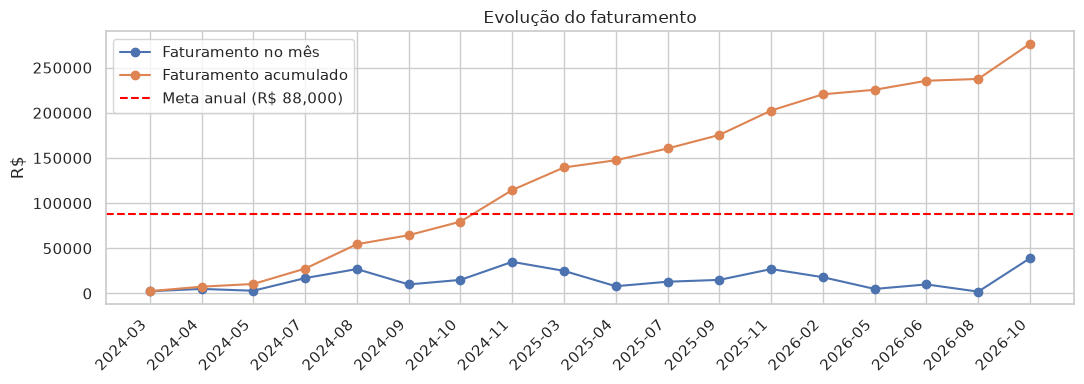

,ano_mes_inicio,valor_total_projeto,faturamento_acumulado
0,2024-03,2500,2500
1,2024-04,5000,7500
2,2024-05,3000,10500
3,2024-07,17000,27500
4,2024-08,27000,54500
5,2024-09,10000,64500
6,2024-10,15000,79500
7,2024-11,35000,114500
8,2025-03,25000,139500
9,2025-04,8000,147500


In [7]:
META_ANUAL = 88000
META_COLABORATIVA = 70000

faturamento_mensal = (
    df.groupby('ano_mes_inicio', as_index=False)['valor_total_projeto']
      .sum()
      .sort_values('ano_mes_inicio')
      .reset_index(drop=True)
)
faturamento_mensal['faturamento_acumulado'] = faturamento_mensal['valor_total_projeto'].cumsum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(faturamento_mensal['ano_mes_inicio'], faturamento_mensal['valor_total_projeto'],
        marker='o', label='Faturamento no mês')
ax.plot(faturamento_mensal['ano_mes_inicio'], faturamento_mensal['faturamento_acumulado'],
        marker='o', label='Faturamento acumulado')
ax.axhline(META_ANUAL, color='red', linestyle='--', label=f'Meta anual (R$ {META_ANUAL:,.0f})')
ax.set_xticklabels(faturamento_mensal['ano_mes_inicio'], rotation=45, ha='right')
ax.set_ylabel('R$')
ax.set_title('Evolução do faturamento')
ax.legend()
plt.tight_layout()
plt.show()

faturamento_mensal


In [8]:
def criar_atributos_temporais(df):
    df = df.copy()
    df['ano_inicio'] = df['data_inicio'].dt.year
    df['mes_inicio'] = df['data_inicio'].dt.month
    df['ano_mes_inicio'] = df['data_inicio'].dt.to_period('M').astype(str)
    df['duracao_dias'] = (df['data_fim'] - df['data_inicio']).dt.days

    inconsistente = df['valor_faturamento_colaborativo'] > df['valor_total_projeto']
    if inconsistente.any():
        print(f'[atenção] {inconsistente.sum()} projeto(s) com faturamento colaborativo maior que o total — revisar na fonte.')

    df['valor_faturamento_proprio'] = (df['valor_total_projeto'] - df['valor_faturamento_colaborativo']).clip(lower=0)
    return df

df = criar_atributos_temporais(df)
df[['nome_projeto', 'valor_total_projeto', 'valor_faturamento_colaborativo', 'valor_faturamento_proprio', 'ano_mes_inicio']].head()


,nome_projeto,valor_total_projeto,valor_faturamento_colaborativo,valor_faturamento_proprio,ano_mes_inicio
0,Projeto Umbra,2500,0,2500,2024-03
1,Projeto Constelação,5000,5000,0,2024-04
2,Projeto Solstício,3000,0,3000,2024-05
3,Projeto Vetor,17000,0,17000,2024-07
4,Projeto Odisseia,7000,0,7000,2024-08


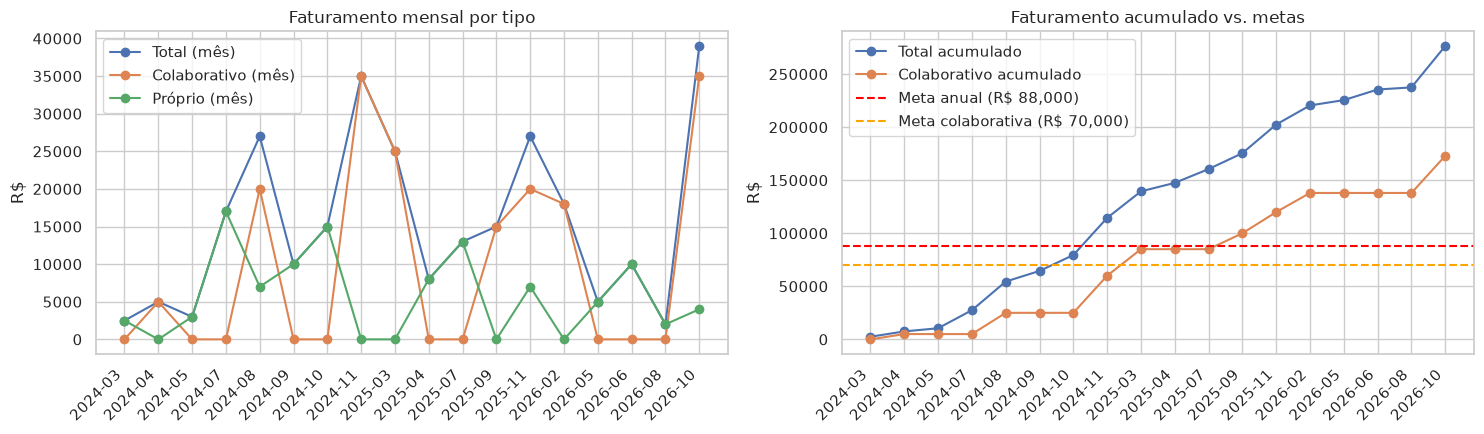

,ano_mes_inicio,faturamento_total,faturamento_colaborativo,faturamento_proprio,faturamento_total_acumulado,faturamento_colaborativo_acumulado
0,2024-03,2500,0,2500,2500,0
1,2024-04,5000,5000,0,7500,5000
2,2024-05,3000,0,3000,10500,5000
3,2024-07,17000,0,17000,27500,5000
4,2024-08,27000,20000,7000,54500,25000
5,2024-09,10000,0,10000,64500,25000
6,2024-10,15000,0,15000,79500,25000
7,2024-11,35000,35000,0,114500,60000
8,2025-03,25000,25000,0,139500,85000
9,2025-04,8000,0,8000,147500,85000


In [9]:
def construir_serie_evolutiva(df):
    serie = (
        df.groupby('ano_mes_inicio', as_index=False)
          .agg(
              faturamento_total=('valor_total_projeto', 'sum'),
              faturamento_colaborativo=('valor_faturamento_colaborativo', 'sum'),
              faturamento_proprio=('valor_faturamento_proprio', 'sum'),
          )
          .sort_values('ano_mes_inicio')
          .reset_index(drop=True)
    )
    serie['faturamento_total_acumulado'] = serie['faturamento_total'].cumsum()
    serie['faturamento_colaborativo_acumulado'] = serie['faturamento_colaborativo'].cumsum()
    return serie

def plotar_evolucao(serie):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

    axes[0].plot(serie['ano_mes_inicio'], serie['faturamento_total'], marker='o', label='Total (mês)')
    axes[0].plot(serie['ano_mes_inicio'], serie['faturamento_colaborativo'], marker='o', label='Colaborativo (mês)')
    axes[0].plot(serie['ano_mes_inicio'], serie['faturamento_proprio'], marker='o', label='Próprio (mês)')
    axes[0].set_xticks(range(len(serie)))
    axes[0].set_xticklabels(serie['ano_mes_inicio'], rotation=45, ha='right')
    axes[0].set_ylabel('R$')
    axes[0].set_title('Faturamento mensal por tipo')
    axes[0].legend()

    axes[1].plot(serie['ano_mes_inicio'], serie['faturamento_total_acumulado'], marker='o', label='Total acumulado')
    axes[1].plot(serie['ano_mes_inicio'], serie['faturamento_colaborativo_acumulado'], marker='o', label='Colaborativo acumulado')
    axes[1].axhline(META_ANUAL, color='red', linestyle='--', label=f'Meta anual (R$ {META_ANUAL:,.0f})')
    axes[1].axhline(META_COLABORATIVA, color='orange', linestyle='--', label=f'Meta colaborativa (R$ {META_COLABORATIVA:,.0f})')
    axes[1].set_xticks(range(len(serie)))
    axes[1].set_xticklabels(serie['ano_mes_inicio'], rotation=45, ha='right')
    axes[1].set_ylabel('R$')
    axes[1].set_title('Faturamento acumulado vs. metas')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

serie_evolutiva = construir_serie_evolutiva(df)
plotar_evolucao(serie_evolutiva)
serie_evolutiva


In [10]:
cluster_base = df.groupby('ano_mes_inicio').agg(
    faturamento_total=('valor_total_projeto', 'sum'),
    faturamento_colaborativo=('valor_faturamento_colaborativo', 'sum'),
    qtd_projetos=('nome_projeto', 'count'),
    qtd_projetos_impacto=('projeto_de_impacto', 'sum'),
    qtd_projetos_concluidos=('status', lambda s: (s == 'Concluído').sum()),
).reset_index()

cluster_base['pct_projetos_impacto'] = cluster_base['qtd_projetos_impacto'] / cluster_base['qtd_projetos']
cluster_base


,ano_mes_inicio,faturamento_total,faturamento_colaborativo,qtd_projetos,qtd_projetos_impacto,qtd_projetos_concluidos,pct_projetos_impacto
0,2024-03,2500,0,1,0,1,0.0
1,2024-04,5000,5000,1,0,1,0.0
2,2024-05,3000,0,1,0,1,0.0
3,2024-07,17000,0,1,0,1,0.0
4,2024-08,27000,20000,2,0,2,0.0
5,2024-09,10000,0,1,0,1,0.0
6,2024-10,15000,0,1,0,1,0.0
7,2024-11,35000,35000,1,1,1,1.0
8,2025-03,25000,25000,1,0,1,0.0
9,2025-04,8000,0,1,0,1,0.0


In [11]:
def construir_base_cluster(df):
    base = df.groupby('ano_mes_inicio').agg(
        faturamento_total=('valor_total_projeto', 'sum'),
        faturamento_colaborativo=('valor_faturamento_colaborativo', 'sum'),
        faturamento_proprio=('valor_faturamento_proprio', 'sum'),
        qtd_projetos=('nome_projeto', 'count'),
        qtd_projetos_impacto=('projeto_de_impacto', 'sum'),
        qtd_projetos_concluidos=('status', lambda s: (s == 'Concluído').sum()),
        csat_medio=('satisfacao', 'mean'),
        qtd_avaliacoes_csat=('satisfacao', 'count'),
    ).reset_index()

    base['pct_projetos_impacto'] = base['qtd_projetos_impacto'] / base['qtd_projetos']
    base['pct_faturamento_colaborativo'] = base['faturamento_colaborativo'] / base['faturamento_total'].replace(0, np.nan)
    base['csat_medio'] = base['csat_medio'].round(2)
    return base

cluster_base = construir_base_cluster(df)
cluster_base


,ano_mes_inicio,faturamento_total,faturamento_colaborativo,faturamento_proprio,qtd_projetos,qtd_projetos_impacto,qtd_projetos_concluidos,csat_medio,qtd_avaliacoes_csat,pct_projetos_impacto,pct_faturamento_colaborativo
0,2024-03,2500,0,2500,1,0,1,5.0,1,0.0,0.000000
1,2024-04,5000,5000,0,1,0,1,5.0,1,0.0,1.000000
2,2024-05,3000,0,3000,1,0,1,4.0,1,0.0,0.000000
3,2024-07,17000,0,17000,1,0,1,4.0,1,0.0,0.000000
4,2024-08,27000,20000,7000,2,0,2,4.5,2,0.0,0.740741
5,2024-09,10000,0,10000,1,0,1,4.0,1,0.0,0.000000
6,2024-10,15000,0,15000,1,0,1,5.0,1,0.0,0.000000
7,2024-11,35000,35000,0,1,1,1,5.0,1,1.0,1.000000
8,2025-03,25000,25000,0,1,0,1,4.0,1,0.0,1.000000
9,2025-04,8000,0,8000,1,0,1,5.0,1,0.0,0.000000


In [12]:
colunas_numericas = [
    'faturamento_total',
    'faturamento_colaborativo',
    'faturamento_proprio',
    'qtd_projetos',
    'qtd_projetos_impacto',
    'pct_projetos_impacto',
    'csat_medio',
]

def padronizar_variaveis(base, colunas_numericas):
    base_scaled = base.copy()
    valores = base[colunas_numericas].copy()
    if valores.isna().any().any():
        print('[aviso] preenchendo nulos com a média da coluna antes de padronizar (ex.: meses sem avaliação de CSAT).')
        valores = valores.fillna(valores.mean(numeric_only=True))
    scaler = StandardScaler()
    base_scaled[colunas_numericas] = scaler.fit_transform(valores)
    return base_scaled, scaler

cluster_base_scaled, scaler = padronizar_variaveis(cluster_base, colunas_numericas)
cluster_base_scaled


[aviso] preenchendo nulos com a média da coluna antes de padronizar (ex.: meses sem avaliação de CSAT).


,ano_mes_inicio,faturamento_total,faturamento_colaborativo,faturamento_proprio,qtd_projetos,qtd_projetos_impacto,qtd_projetos_concluidos,csat_medio,qtd_avaliacoes_csat,pct_projetos_impacto,pct_faturamento_colaborativo
0,2024-03,-1.177629,-0.772499,-0.610494,-0.417029,-0.447214,1,1.016511,1,-0.427179,0.000000
1,2024-04,-0.948716,-0.370621,-1.080105,-0.417029,-0.447214,1,1.016511,1,-0.427179,1.000000
2,2024-05,-1.131847,-0.772499,-0.516572,-0.417029,-0.447214,1,-1.626418,1,-0.427179,0.000000
3,2024-07,0.150065,-0.772499,2.113248,-0.417029,-0.447214,1,-1.626418,1,-0.427179,0.000000
4,2024-08,1.065716,0.835013,0.234805,1.459601,-0.447214,2,-0.304953,2,-0.427179,0.740741
5,2024-09,-0.490891,-0.772499,0.798338,-0.417029,-0.447214,1,-1.626418,1,-0.427179,0.000000
6,2024-10,-0.033065,-0.772499,1.737559,-0.417029,-0.447214,1,1.016511,1,-0.427179,0.000000
7,2024-11,1.798237,2.040646,-1.080105,-0.417029,2.236068,1,1.016511,1,2.648509,1.000000
8,2025-03,0.882586,1.236891,-1.080105,-0.417029,-0.447214,1,-1.626418,1,-0.427179,1.000000
9,2025-04,-0.674021,-0.772499,0.422650,-0.417029,-0.447214,1,1.016511,1,-0.427179,0.000000


In [17]:
def exportar_dados(df, base, base_scaled, scaler, pasta='dados_tratados'):
    pasta = Path(pasta)
    pasta.mkdir(exist_ok=True)

    df.to_csv(pasta / 'projetos_tratados.csv', index=False)
    base.to_csv(pasta / 'base_cluster_mensal.csv', index=False)
    base_scaled.to_csv(pasta / 'base_cluster_mensal_padronizada.csv', index=False)
    joblib.dump(scaler, pasta / 'scaler_cluster.pkl')

    metadados = {
        'executado_em': datetime.now().isoformat(timespec='seconds'),
        'qtd_projetos': int(len(df)),
        'qtd_periodos_cluster': int(len(base)),
        'meta_anual': META_ANUAL,
        'meta_colaborativa': META_COLABORATIVA,
        'colunas_projetos': list(df.columns),
        'colunas_cluster_base': list(base.columns),
    }
    with open(pasta / 'metadados_execucao.json', 'w', encoding='utf-8') as f:
        json.dump(metadados, f, ensure_ascii=False, indent=2)

    print(f'Dados exportados em: {pasta.resolve()}')
    for arquivo in sorted(pasta.iterdir()):
        print(' -', arquivo.name)

exportar_dados(df, cluster_base, cluster_base_scaled, scaler)

Dados exportados em: /home/mazzerr/Downloads/asimovjr/semana 15-16/Project_DEX_Asimov/dados_tratados
 - base_cluster_mensal.csv
 - base_cluster_mensal_padronizada.csv
 - metadados_execucao.json
 - projetos_tratados.csv
 - scaler_cluster.pkl


In [20]:
def executar_pipeline(fonte, pasta_saida='dados_tratados'):
    print('Iniciando pipeline de tratamento de dados...\n')

    df = carregar_dados(fonte)
    df = padronizar_colunas(df)
    df = limpar_dados(df)
    df = criar_atributos_temporais(df)

    serie_evolutiva = construir_serie_evolutiva(df)
    cluster_base = construir_base_cluster(df)
    cluster_base_scaled, scaler = padronizar_variaveis(cluster_base, colunas_numericas)

    exportar_dados(df, cluster_base, cluster_base_scaled, scaler, pasta_saida)
    print('\nPipeline concluído com sucesso.')

    return {
        'df': df,
        'serie_evolutiva': serie_evolutiva,
        'cluster_base': cluster_base,
        'cluster_base_scaled': cluster_base_scaled,
        'scaler': scaler,
    }

# Execução única, de ponta a ponta — use esta célula para atualizar tudo de uma vez
resultado = executar_pipeline(url)


Iniciando pipeline de tratamento de dados...

Projetos concluídos sem CSAT registrado: 0
Projetos não concluídos com CSAT já registrado (incomum, revisar): 0

Linhas duplicadas: 0

Valores nulos por coluna:
data_registro                     0
nome_projeto                      0
area                              0
responsavel                       0
cliente                           0
satisfacao                        7
valor_total_projeto               0
valor_faturamento_colaborativo    0
projeto_de_impacto                0
data_inicio                       0
data_fim                          0
status                            0
dtype: int64

Categorias de área: <StringArray>
['Mobile', 'Sites', 'Desktop', 'Dados']
Length: 4, dtype: str
Categorias de status: <StringArray>
['Concluído', 'Em andamento', 'Iniciado']
Length: 3, dtype: str
[aviso] preenchendo nulos com a média da coluna antes de padronizar (ex.: meses sem avaliação de CSAT).
Dados exportados em: /home/mazzerr/Downloads/as